# 01 — Data Exploration

This notebook explores the tabular MDVP voice-feature dataset used for Parkinson’s Disease detection.

Because the original dataset is private, no raw patient data is shared in this repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path(r"D:\Datasets\PD-alldata.csv")

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Dataset path: D:\Datasets\PD-alldata.csv
Dataset exists: True


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (228, 21)


,name,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,...,vAm,ATRI,FTRI,DUV,DVB,DSH,VTI,SPI,NHR,status
0,AF_181203_1403.raw,0.6,31,0.3,0.3,0.6,1.3,3.6,0.30,2.1,...,36.2,2.1,0.4,0,0,0,13.71,4.14,27.39,1
1,AF_181203_1610.raw,1.3,60,0.8,0.6,0.9,1.8,10.6,1.06,5.3,...,26.0,6.2,0.6,0,0,0,12.05,5.24,22.47,1
2,AF_181205_1026.raw,1.4,75,0.9,0.7,1.3,2.7,12.7,1.28,6.7,...,39.8,7.6,1.0,0,0,0,11.82,7.56,16.12,1
3,AF_181205_1402.raw,1.0,53,0.6,0.6,0.9,1.3,5.7,0.50,3.5,...,24.5,3.2,0.7,0,0,0,17.71,5.48,16.74,1
4,AF_181205_1426.raw,1.8,90,1.2,0.9,1.2,1.5,9.7,1.17,4.8,...,72.5,4.6,0.9,0,0,0,13.93,3.94,24.29,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    228 non-null    object 
 1   jitt    228 non-null    float64
 2   jita    228 non-null    int64  
 3   RAP     228 non-null    float64
 4   PPQ     228 non-null    float64
 5   sPPQ    228 non-null    float64
 6   vfo     228 non-null    float64
 7   shim    228 non-null    float64
 8   shdb    228 non-null    float64
 9   APQ     228 non-null    float64
 10  sAPQ    228 non-null    float64
 11  vAm     228 non-null    float64
 12  ATRI    228 non-null    float64
 13  FTRI    228 non-null    float64
 14  DUV     228 non-null    int64  
 15  DVB     228 non-null    int64  
 16  DSH     228 non-null    int64  
 17  VTI     228 non-null    float64
 18  SPI     228 non-null    float64
 19  NHR     228 non-null    float64
 20  status  228 non-null    int64  
dtypes: float64(15), int64(5), object(1)
mem

In [5]:
df.columns.tolist()

['name',
 'jitt',
 'jita',
 'RAP',
 'PPQ',
 'sPPQ',
 'vfo',
 'shim',
 'shdb',
 'APQ',
 'sAPQ',
 'vAm',
 'ATRI',
 'FTRI',
 'DUV',
 'DVB',
 'DSH',
 'VTI',
 'SPI',
 'NHR',
 'status']

In [6]:
TARGET_COL = "status"   # change this if your label column has a different name

print("Target column:", TARGET_COL)
print("Target exists:", TARGET_COL in df.columns)

Target column: status
Target exists: True


In [7]:
df[TARGET_COL].value_counts()

status
1    187
0     41
Name: count, dtype: int64

In [8]:
(df[TARGET_COL].value_counts(normalize=True) * 100).round(2)

status
1    82.02
0    17.98
Name: proportion, dtype: float64

In [9]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

summary

,column,dtype,missing_values,missing_percent,unique_values
name,name,object,0,0.0,224
jitt,jitt,float64,0,0.0,48
jita,jita,int64,0,0.0,103
RAP,RAP,float64,0,0.0,42
PPQ,PPQ,float64,0,0.0,40
sPPQ,sPPQ,float64,0,0.0,47
vfo,vfo,float64,0,0.0,66
shim,shim,float64,0,0.0,101
shdb,shdb,float64,0,0.0,105
APQ,APQ,float64,0,0.0,78


In [10]:
summary.to_csv(METRICS_DIR / "data_summary.csv", index=False)
print("Saved:", METRICS_DIR / "data_summary.csv")

Saved: ..\results\metrics\data_summary.csv


In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 4


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

print("Number of numeric features:", len(numeric_cols))
numeric_cols

Number of numeric features: 19


['jitt',
 'jita',
 'RAP',
 'PPQ',
 'sPPQ',
 'vfo',
 'shim',
 'shdb',
 'APQ',
 'sAPQ',
 'vAm',
 'ATRI',
 'FTRI',
 'DUV',
 'DVB',
 'DSH',
 'VTI',
 'SPI',
 'NHR']

In [14]:
numeric_stats = df[numeric_cols].describe().T
numeric_stats

,count,mean,std,min,25%,50%,75%,max
jitt,228.0,2.246491,5.278828,0.20,0.300,0.500,1.0000,38.50
jita,228.0,252.289474,712.158637,11.00,25.750,39.500,88.0000,5630.00
RAP,228.0,1.342544,3.234272,0.00,0.200,0.300,0.5250,21.70
PPQ,228.0,1.525439,3.748699,0.10,0.200,0.300,0.6000,25.20
sPPQ,228.0,2.185526,4.589791,0.30,0.500,0.700,1.0000,26.30
vfo,228.0,3.380702,5.794086,0.50,1.000,1.400,2.3000,37.50
shim,228.0,6.836404,6.988653,1.30,3.300,4.350,7.2250,45.40
shdb,228.0,0.657456,0.773977,0.11,0.290,0.390,0.6925,5.44
APQ,228.0,4.295614,4.504660,0.80,2.100,2.800,4.6250,29.30
sAPQ,228.0,8.099123,6.094462,2.10,4.500,6.200,8.8000,38.70


In [15]:
numeric_stats.to_csv(METRICS_DIR / "numeric_feature_statistics.csv")
print("Saved:", METRICS_DIR / "numeric_feature_statistics.csv")

Saved: ..\results\metrics\numeric_feature_statistics.csv


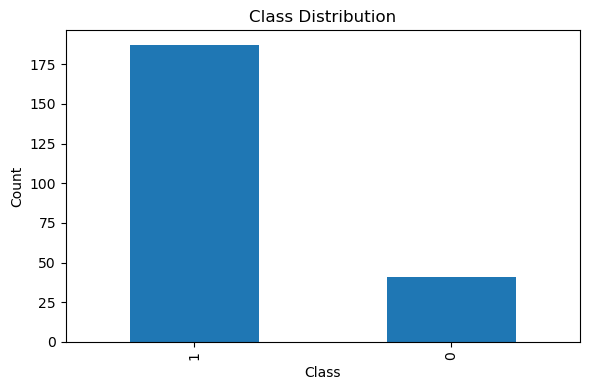

In [16]:
target_counts = df[TARGET_COL].value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

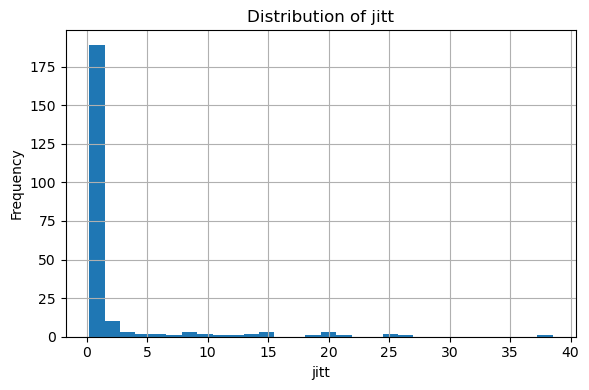

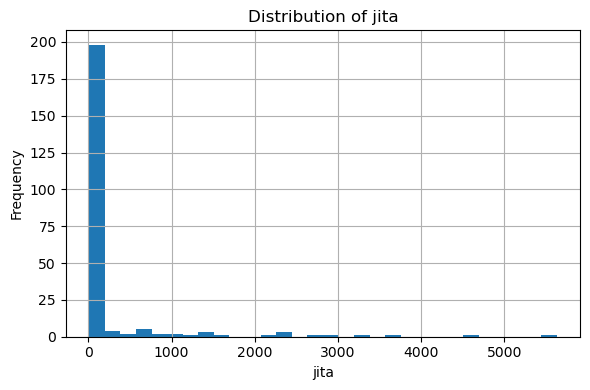

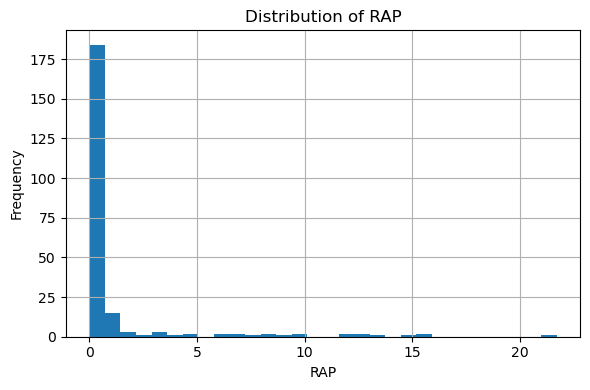

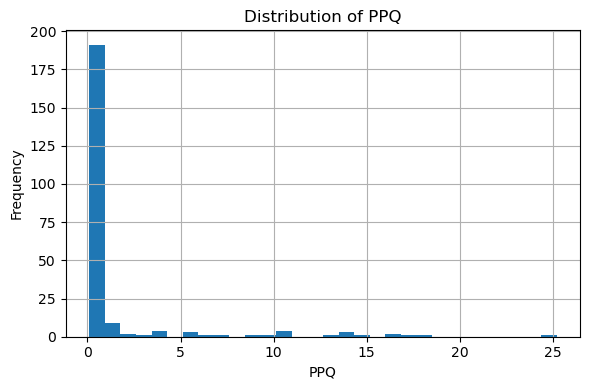

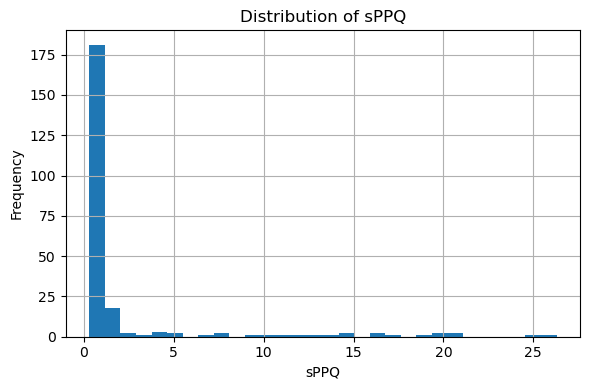

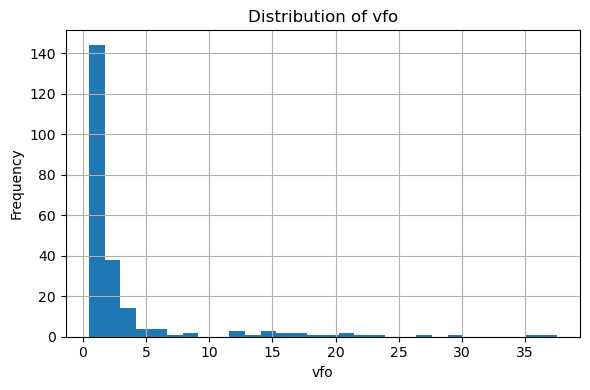

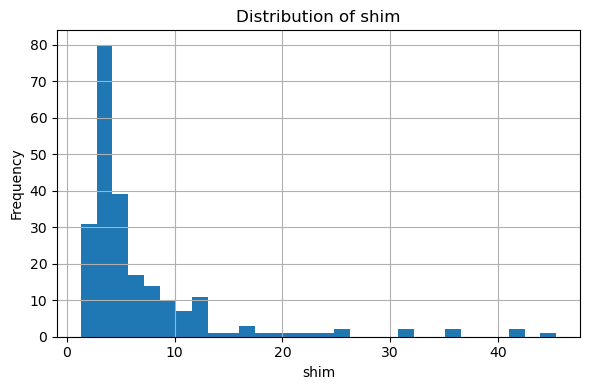

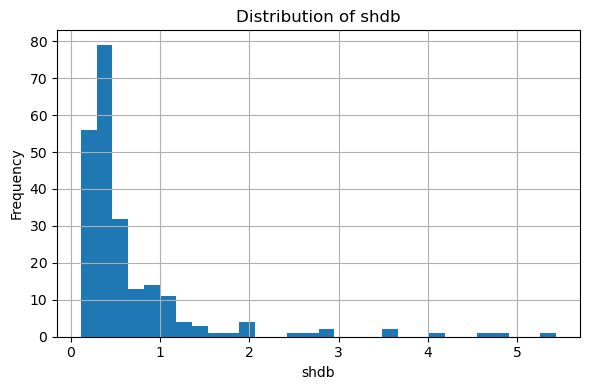

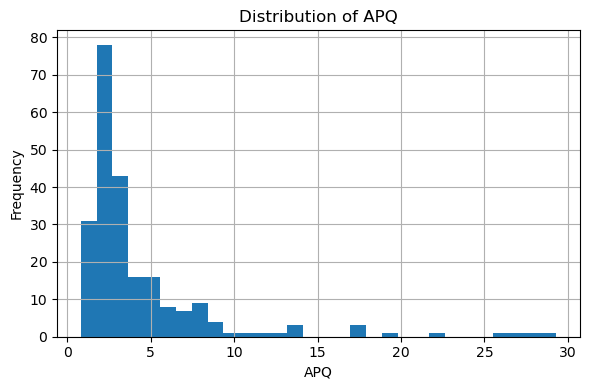

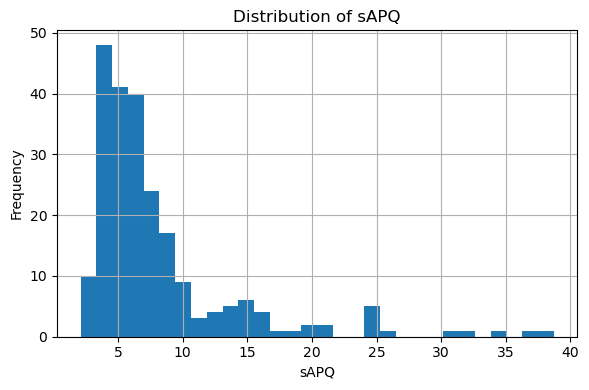

In [17]:
features_to_plot = numeric_cols[:10]

for col in features_to_plot:
    safe_col_name = col.replace("/", "_").replace(":", "_").replace(" ", "_")
    
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"distribution_{safe_col_name}.png", dpi=300)
    plt.show()

<Figure size 600x400 with 0 Axes>

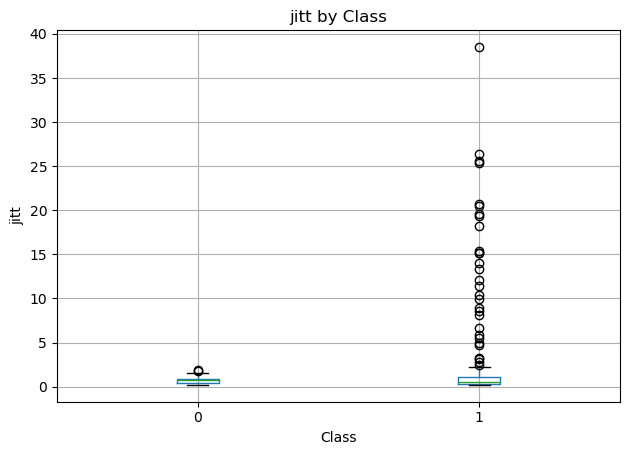

<Figure size 600x400 with 0 Axes>

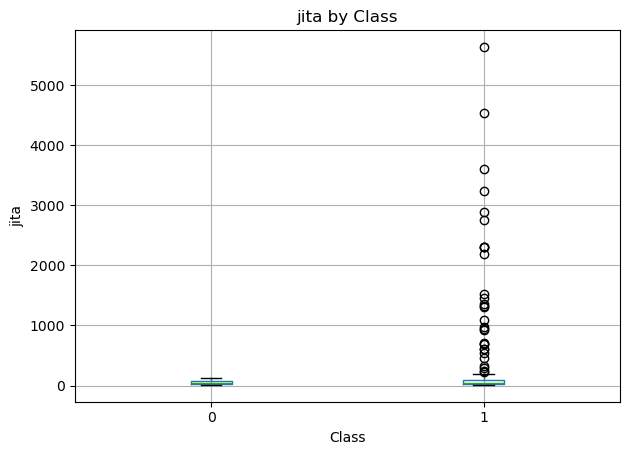

<Figure size 600x400 with 0 Axes>

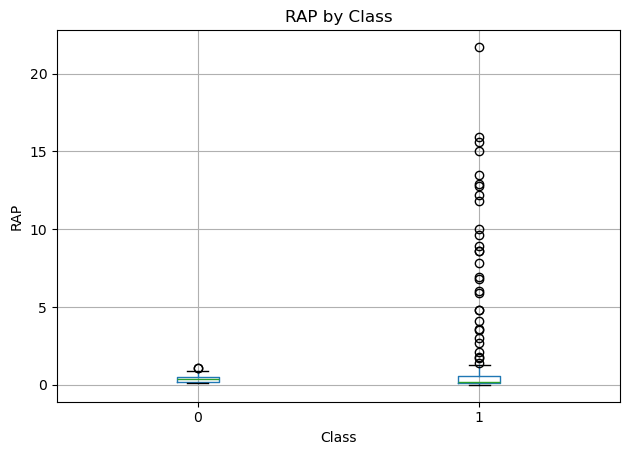

<Figure size 600x400 with 0 Axes>

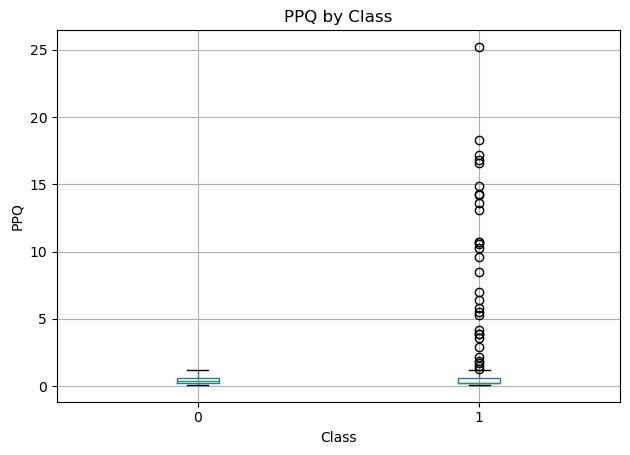

<Figure size 600x400 with 0 Axes>

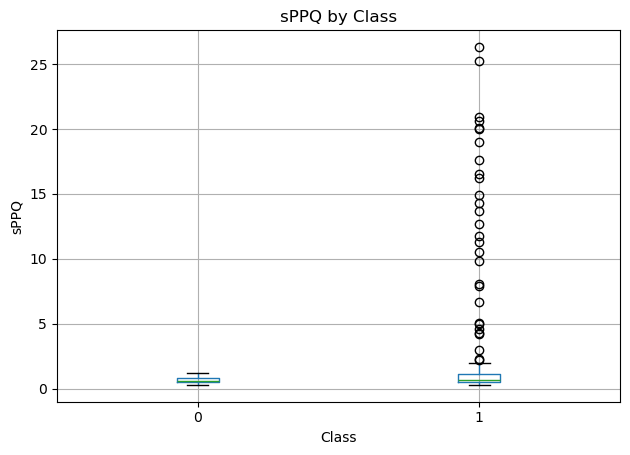

<Figure size 600x400 with 0 Axes>

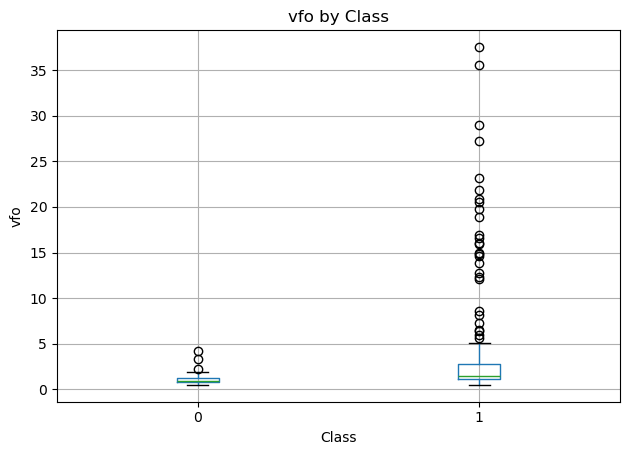

<Figure size 600x400 with 0 Axes>

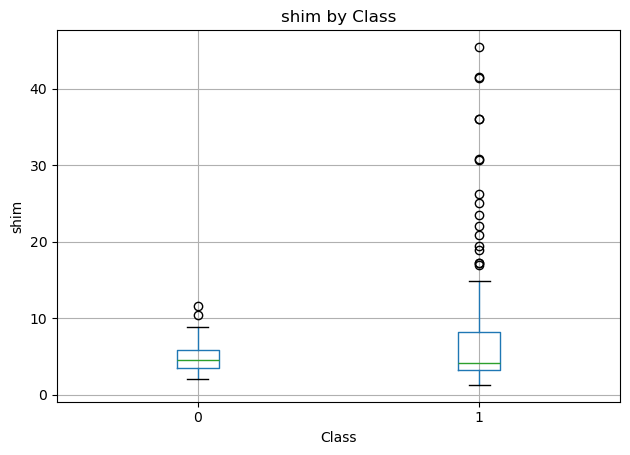

<Figure size 600x400 with 0 Axes>

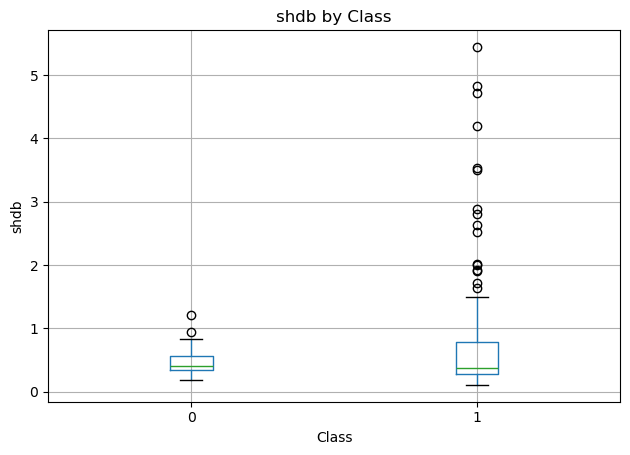

<Figure size 600x400 with 0 Axes>

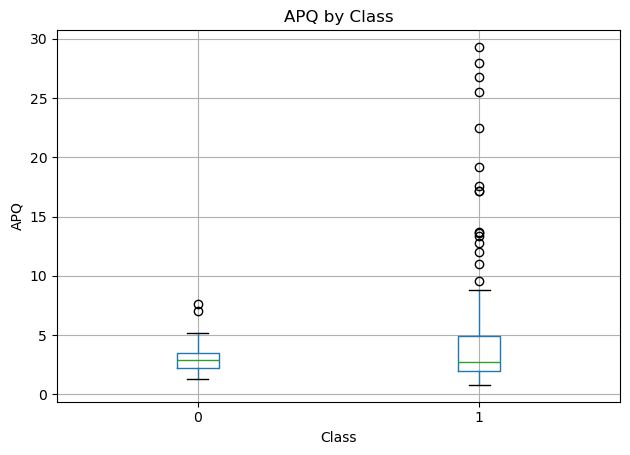

<Figure size 600x400 with 0 Axes>

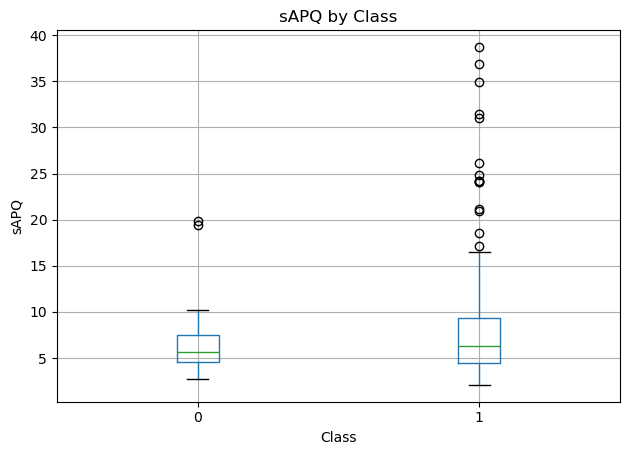

In [18]:
features_to_plot = numeric_cols[:10]

for col in features_to_plot:
    safe_col_name = col.replace("/", "_").replace(":", "_").replace(" ", "_")
    
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by=TARGET_COL)
    plt.title(f"{col} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"boxplot_{safe_col_name}.png", dpi=300)
    plt.show()

In [19]:
corr = df[numeric_cols].corr()
corr.head()

,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,sAPQ,vAm,ATRI,FTRI,DUV,DVB,DSH,VTI,SPI,NHR
jitt,1.000000,0.936599,0.998117,0.993646,0.973862,0.935948,0.757690,0.730674,0.760116,0.659909,0.362187,0.320953,0.916558,NaN,NaN,NaN,-0.110143,0.302327,-0.105698
jita,0.936599,1.000000,0.936087,0.942132,0.894409,0.841972,0.646341,0.581925,0.644668,0.537278,0.316065,0.242893,0.832901,NaN,NaN,NaN,-0.163627,0.371586,-0.183019
RAP,0.998117,0.936087,1.000000,0.995838,0.978511,0.932214,0.739347,0.710545,0.739995,0.641478,0.356963,0.313746,0.923848,NaN,NaN,NaN,-0.106726,0.286561,-0.102125
PPQ,0.993646,0.942132,0.995838,1.000000,0.985718,0.930810,0.715436,0.685912,0.720093,0.620244,0.345305,0.312678,0.930235,NaN,NaN,NaN,-0.111163,0.293552,-0.114283
sPPQ,0.973862,0.894409,0.978511,0.985718,1.000000,0.936138,0.692322,0.677607,0.699002,0.620283,0.350075,0.327013,0.942435,NaN,NaN,NaN,-0.084678,0.248013,-0.092645


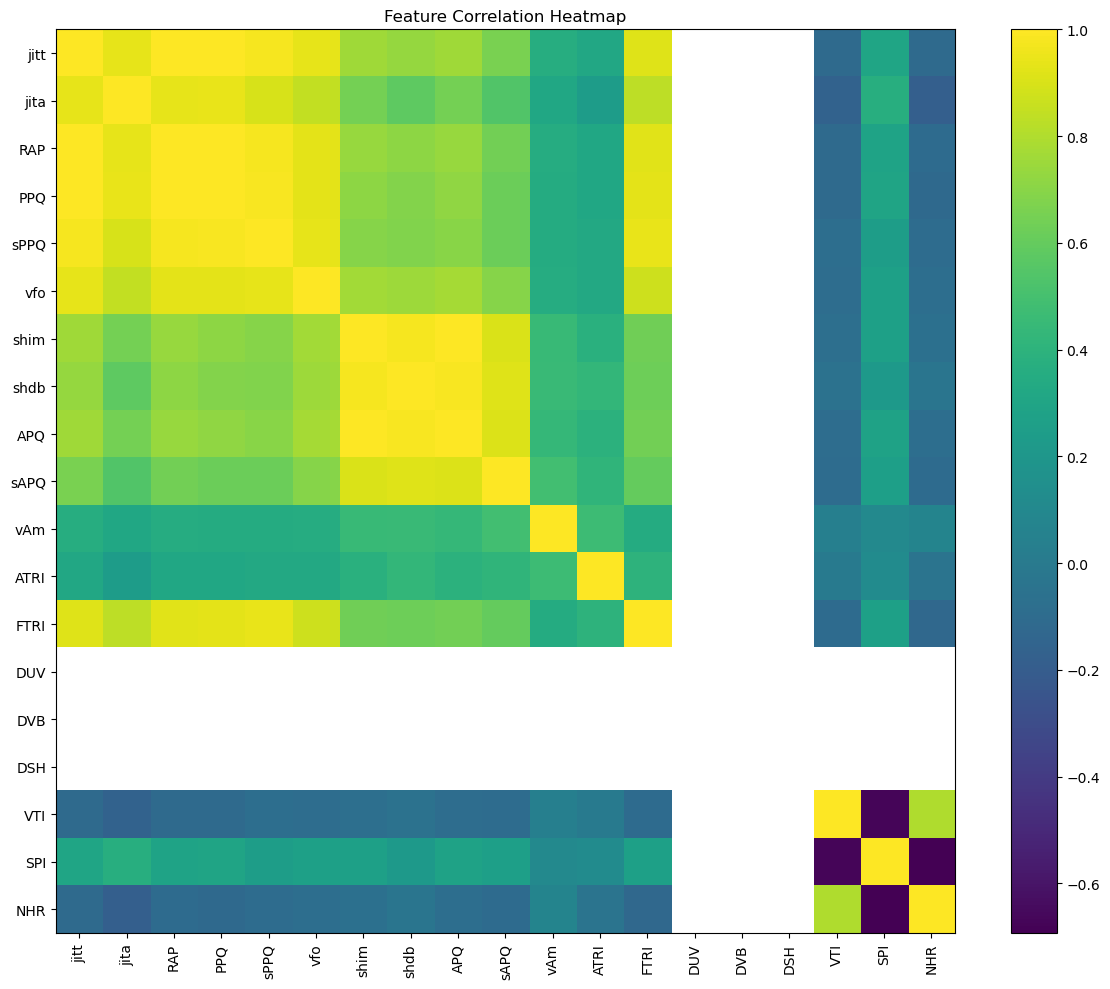

In [20]:
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

In [21]:
corr.to_csv(METRICS_DIR / "correlation_matrix.csv")
print("Saved:", METRICS_DIR / "correlation_matrix.csv")

Saved: ..\results\metrics\correlation_matrix.csv


In [22]:
target_corr = df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
target_corr = target_corr.sort_values(key=abs, ascending=False)

target_corr.head(15)

vAm     0.334104
VTI     0.239893
ATRI    0.200657
vfo     0.180570
FTRI    0.171194
sPPQ    0.153131
PPQ     0.137222
RAP     0.136050
jitt    0.135744
jita    0.134053
sAPQ    0.122945
NHR     0.121565
shim    0.120199
shdb    0.119868
APQ     0.114898
Name: status, dtype: float64

In [23]:
target_corr.to_csv(METRICS_DIR / "target_feature_correlations.csv")
print("Saved:", METRICS_DIR / "target_feature_correlations.csv")

Saved: ..\results\metrics\target_feature_correlations.csv


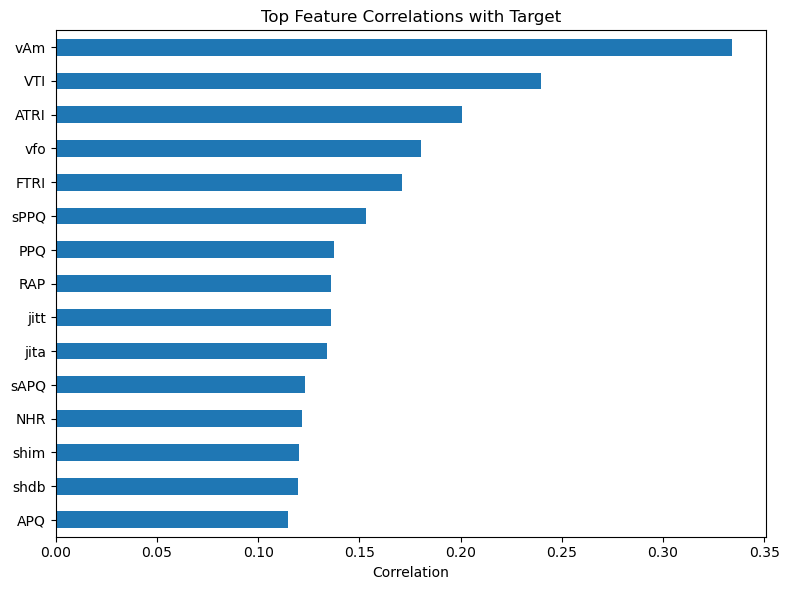

In [24]:
plt.figure(figsize=(8, 6))
target_corr.head(15).sort_values().plot(kind="barh")
plt.title("Top Feature Correlations with Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_target_correlations.png", dpi=300)
plt.show()

## EDA Summary

Key observations:

1. The dataset contains tabular MDVP voice features for Parkinson’s Disease detection.
2. The target variable represents Parkinson’s Disease status.
3. Class distribution was checked to identify possible imbalance.
4. Missing values and duplicate rows were examined before modeling.
5. Numeric feature statistics were generated and saved.
6. Feature distributions and class-based boxplots were created.
7. Correlation analysis was performed to identify potentially informative features.

These findings will guide preprocessing and model training in the next notebook.